In [1]:
import os
import pandas as pd
import scanpy as sc
import scipy as sp
import anndata as ad
import numpy as np
import muon as mu
import seaborn as sns
from scipy import stats
import scvi
import mudata as md
import torch
import cell2net
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from captum.attr import IntegratedGradients
md.set_options(pull_on_update=False)

/home/rb/miniconda3/envs/cell2net_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
in_dir = "../scEPInformer/02_prepare_data"
out_dir = "../scEPInformer/12_interpretation"

os.makedirs(out_dir, exist_ok=True)

In [3]:
mdata = md.read_h5mu(f'{in_dir}/mdata.h5mu')

In [4]:
mdata.obs['total_counts_rna_log'] = np.log10(mdata.obs['total_counts_rna'])
mdata.obs['total_counts_atac_log'] = np.log10(mdata.obs['total_counts_atac'])

In [5]:
genes = mdata.uns["peak_to_gene"]['gene'].unique().tolist()

In [6]:
model_jc = cell2net.pd.model.Cell2Net_Jc(mdata=mdata, 
                                   gene="ZEB2", 
                                   covariates=['total_counts_rna_log', 'total_counts_atac_log'])

/home/rb/miniconda3/envs/cell2net_env/lib/python3.11/site-packages/cell2net/prediction/model/_cell2net.py:421: ImplicitModificationWarning: Setting element `.obsm['tf']` of view, initializing view as actual.
  adata_rna.obsm["tf"] = mdata[rna_mod][:, df_tfs.index].layers["counts"].copy()  # type: ignore


In [7]:
model_jc.summary

'gene_name: ZEB2, n_peaks: 79, peak_len: 256, n_tfs: 513, n_covariates: 2, n_filters: [64, 32, 32, 16], n_channels: 4, kernel_size: 12, n_dims: 16'

In [ ]:
model_jc

In [14]:
model_jc.train(max_epochs=30, device_name="cuda:0", batch_size=128, lr=1e-04)

Split dataset for training and validation; training size is 0.8


100%|██████████| 30/30 [01:09<00:00,  2.30s/it]


In [17]:
model_jc.history

,epochs,train_loss,valid_loss
0,0,-6.608468,-1.784118
1,1,-6.418860,-1.778838
2,2,-6.530427,-1.692284
3,3,-6.577689,-1.739699
4,4,-6.608927,-1.739465
5,5,-6.579154,-1.720539
6,6,-6.561261,-1.782327
7,7,-6.612281,-1.762550
8,8,-6.569643,-1.784933
9,9,-6.635265,-1.772794


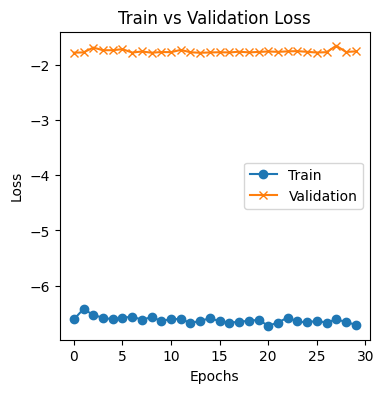

In [18]:
cell2net.pl.train_history(model_jc)

In [19]:
model = cell2net.pd.model.Cell2Net(mdata=mdata, 
                                   gene="ZEB2", 
                                   covariates=['total_counts_rna_log', 'total_counts_atac_log'])

/home/rb/miniconda3/envs/cell2net_env/lib/python3.11/site-packages/cell2net/prediction/model/_cell2net.py:62: ImplicitModificationWarning: Setting element `.obsm['tf']` of view, initializing view as actual.
  adata_rna.obsm["tf"] = mdata[rna_mod][:, df_tfs.index].layers["counts"].copy()  # type: ignore


In [20]:
model.train(max_epochs=30, device_name="cuda:0", batch_size=128, lr=1e-04)

Split dataset for training and validation; training size is 0.8


100%|██████████| 30/30 [03:20<00:00,  6.67s/it]


In [21]:
model.history

,epochs,train_loss,valid_loss
0,0,-4.231530,-1.524086
1,1,-6.085422,-1.685872
2,2,-6.405905,-1.734385
3,3,-6.670889,-1.740477
4,4,-6.722188,-1.759182
5,5,-6.815863,-1.760129
6,6,-6.842357,-1.760254
7,7,-6.947154,-1.754498
8,8,-6.999172,-1.772206
9,9,-7.015249,-1.763251


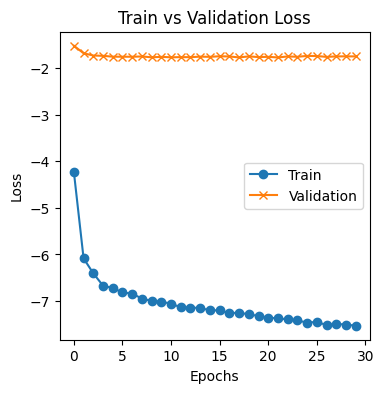

In [22]:
cell2net.pl.train_history(model)

In [17]:
model.save(dir_path=out_dir)

In [18]:
model.load(dir_path=out_dir)

In [21]:
peak_seq_attr, peak_acc_attr, tf_exp_attr = cell2net.ip.compute_attribution(model)

In [22]:
df_p2g = cell2net.ip.peak_to_gene(model.mdata, peak_acc_attr)

In [30]:
avg_peak_acc_attr = np.mean(peak_acc_attr, axis=0)

In [25]:
# avg_peak_acc_attr[avg_peak_acc_attr < 0] = 0

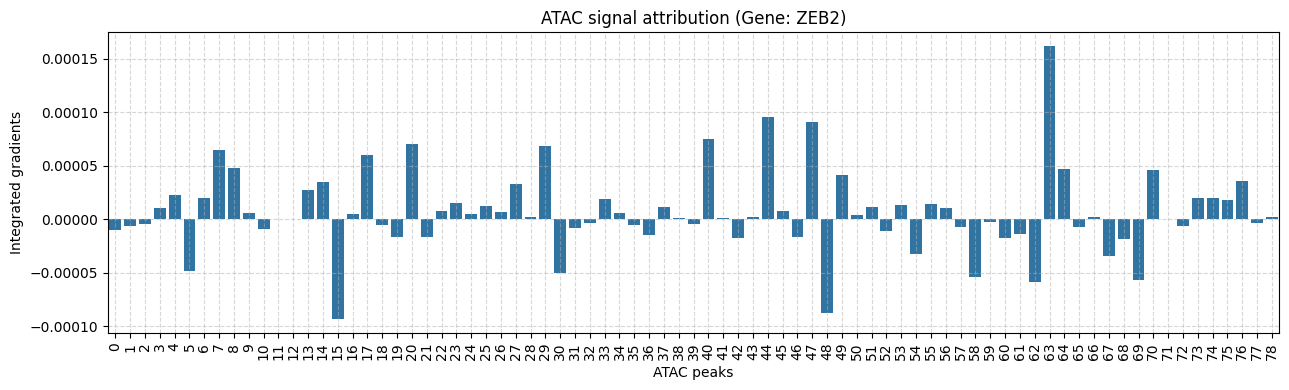

In [31]:
plt.figure(figsize=(13, 4))
sns.barplot(avg_peak_acc_attr)
plt.title("ATAC signal attribution (Gene: ZEB2)")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=90)
plt.xlabel("ATAC peaks")
plt.ylabel("Integrated gradients")
plt.tight_layout()